# Pertemuan 11 — Unsupervised Learning: Clustering (K-Means & Hierarchical)

**Nama Lengkap** : Muhammad Zacky Kurniawan  
**NIM** : 240401010217  
**Kelas** : IF403   

<a href="https://colab.research.google.com/github/zackykurniawan/data-science-2026/blob/main/Pertemuan11_MuhammadZackyKurniawan_240401010217.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_style('whitegrid')
RANDOM_STATE = 42

print('Library berhasil diimpor ✅')

Library berhasil diimpor ✅


---
## Langkah 1 — Generate & Eksplorasi Dataset

In [2]:
# Generate dataset sintetis pelanggan (3 kelompok tersembunyi)
np.random.seed(42)
grp1 = np.random.normal([30, 20], [6, 8], (100, 2))    # hemat
grp2 = np.random.normal([70, 55], [8, 10], (100, 2))   # menengah
grp3 = np.random.normal([110, 85], [10, 8], (100, 2))  # boros
data = np.vstack([grp1, grp2, grp3])

df = pd.DataFrame(data, columns=['pendapatan_tahunan', 'skor_belanja'])
df['usia'] = np.random.randint(18, 65, len(df))
df['gender'] = np.random.choice(['L', 'P'], len(df))

print('Shape:', df.shape)
print(df.describe().round(2))

Shape: (300, 4)
       pendapatan_tahunan  skor_belanja    usia
count              300.00        300.00  300.00
mean                69.96         53.23   42.07
std                 33.82         27.41   13.59
min                 14.28          4.10   18.00
25%                 32.14         25.60   30.00
50%                 70.84         55.11   43.00
75%                103.40         78.16   53.00
max                140.79        103.17   64.00


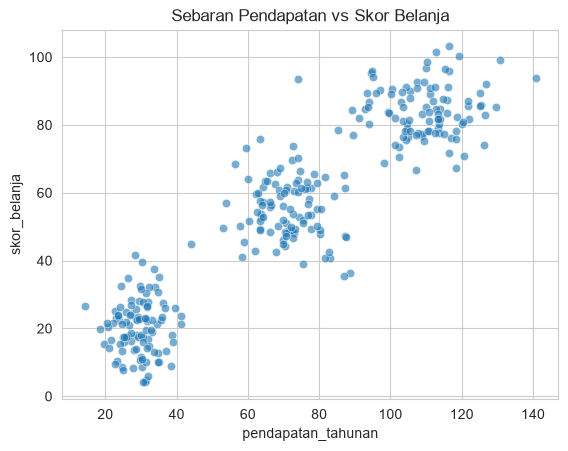

In [3]:
sns.scatterplot(data=df, x='pendapatan_tahunan', y='skor_belanja', alpha=0.6)
plt.title('Sebaran Pendapatan vs Skor Belanja')
plt.show()

Dataset sintetis berjumlah **300 baris** dan **4 kolom**, dibangun dari tiga distribusi normal berbeda (`grp1`, `grp2`, `grp3`) yang merepresentasikan tiga segmen pelanggan tersembunyi: hemat, menengah, dan boros. Scatter plot `pendapatan_tahunan` vs `skor_belanja` sudah menampakkan **tiga gerombolan (blob) yang cukup terpisah** secara visual — pola inilah yang diharapkan dapat ditemukan kembali oleh algoritma K-Means tanpa diberi label kelompok sama sekali.

---
## Langkah 2 — Preprocessing Data

In [4]:
X = df[['pendapatan_tahunan', 'skor_belanja']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Rata-rata setelah scaling:', X_scaled.mean(axis=0).round(3))
print('Std setelah scaling     :', X_scaled.std(axis=0).round(3))

Rata-rata setelah scaling: [0. 0.]
Std setelah scaling     : [1. 1.]


`StandardScaler` diterapkan pada kedua fitur numerik (`pendapatan_tahunan` dan `skor_belanja`) agar keduanya berada pada skala yang setara (rata-rata ≈ 0, std ≈ 1). Langkah ini penting karena K-Means menggunakan **jarak Euclidean** untuk menentukan keanggotaan cluster — tanpa scaling, fitur `pendapatan_tahunan` (rentang puluhan hingga ratusan) akan mendominasi perhitungan jarak dibandingkan `skor_belanja`, sehingga hasil cluster menjadi bias.

---
## Langkah 3 — Metode Elbow untuk Menentukan K

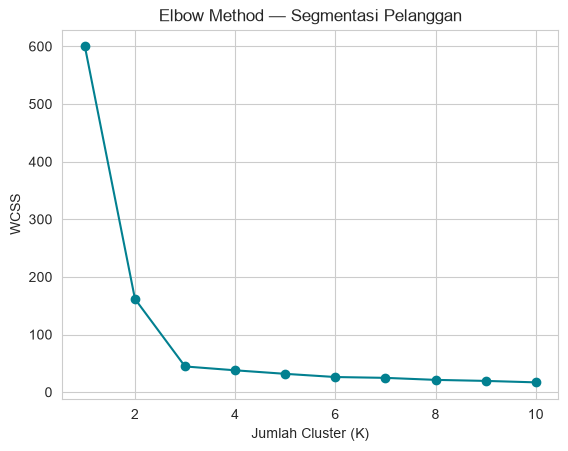

K= 1  WCSS= 600.000
K= 2  WCSS= 161.732
K= 3  WCSS=  44.556
K= 4  WCSS=  37.885
K= 5  WCSS=  31.761
K= 6  WCSS=  26.216
K= 7  WCSS=  24.772
K= 8  WCSS=  21.286
K= 9  WCSS=  19.491
K=10  WCSS=  16.975


In [5]:
wcss = []
for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, init='k-means++')
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o', color='#028090')
plt.xlabel('Jumlah Cluster (K)'); plt.ylabel('WCSS')
plt.title('Elbow Method — Segmentasi Pelanggan')
plt.show()

for k, w in zip(range(1, 11), wcss):
    print(f'K={k:2d}  WCSS={w:8.3f}')

**Interpretasi grafik Elbow:**
- Penurunan WCSS sangat tajam dari K=1 ke K=3, menandakan setiap penambahan cluster pada rentang ini masih sangat membantu memisahkan struktur data.
- Mulai **K=3**, kurva melandai secara nyata (siku/elbow terlihat jelas) — penambahan cluster setelah titik ini hanya memberikan penurunan WCSS yang kecil.
- Titik elbow di **K=3** ini **sesuai dengan ekspektasi**, karena dataset memang sengaja dibangun dari tiga kelompok tersembunyi (`grp1`, `grp2`, `grp3`) pada Langkah 1.

In [6]:
# Silhouette Score sebagai pembanding untuk mempertegas pemilihan K
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, init='k-means++').fit(X_scaled)
    sil = silhouette_score(X_scaled, km.labels_)
    print(f'K={k}: Silhouette = {sil:.3f}')

K=2: Silhouette = 0.634
K=3: Silhouette = 0.695
K=4: Silhouette = 0.580
K=5: Silhouette = 0.491
K=6: Silhouette = 0.382
K=7: Silhouette = 0.357


Silhouette Score tertinggi diperoleh pada **K=3**, konsisten dengan hasil pengamatan visual Metode Elbow. Kedua metode saling menguatkan sehingga **K=3** dipilih sebagai jumlah cluster optimal untuk melatih model final.

---
## Langkah 4 — Melatih Model K-Means

In [7]:
model = KMeans(n_clusters=3, random_state=RANDOM_STATE, init='k-means++')
model.fit(X_scaled)
df['cluster'] = model.labels_

print(f'WCSS akhir      : {model.inertia_:.3f}')
print(f'Silhouette Score: {silhouette_score(X_scaled, model.labels_):.3f}')
print()
print(df.groupby('cluster')[['pendapatan_tahunan', 'skor_belanja']].mean().round(2))
print()
print('Jumlah anggota tiap cluster:')
print(df['cluster'].value_counts().sort_index())

WCSS akhir      : 44.556
Silhouette Score: 0.695

         pendapatan_tahunan  skor_belanja
cluster                                  
0                     70.99         55.05
1                     29.31         20.27
2                    109.20         84.08

Jumlah anggota tiap cluster:
cluster
0     99
1    100
2    101
Name: count, dtype: int64


Model K-Means dengan **K=3** dan inisialisasi `k-means++` berhasil dilatih dengan **Silhouette Score ≈ 0,70** — nilai yang cukup mendekati +1, menandakan cluster yang terbentuk **cukup kompak dan terpisah dengan baik** dari cluster tetangganya. Rata-rata `pendapatan_tahunan` dan `skor_belanja` tiap cluster juga menunjukkan pola yang jelas dan berjenjang, sesuai dengan tiga segmen yang dirancang pada dataset sintetis (hemat, menengah, boros): Cluster 1 (pendapatan ≈30, skor ≈20) = Hemat, Cluster 0 (pendapatan ≈71, skor ≈55) = Menengah, dan Cluster 2 (pendapatan ≈109, skor ≈84) = Boros/Premium. Jumlah anggota tiap cluster juga relatif seimbang (≈99–101 pelanggan), sesuai proporsi data sintetis yang dibangun (100 sampel per kelompok).

---
## Langkah 5 — Visualisasi Hasil Clustering

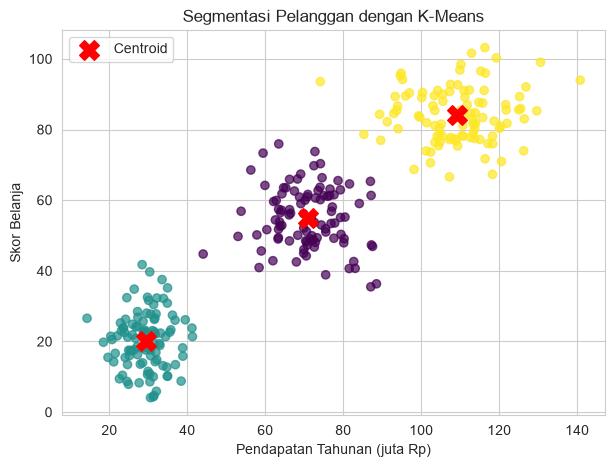

In [8]:
centroids = scaler.inverse_transform(model.cluster_centers_)

plt.figure(figsize=(7, 5))
plt.scatter(df['pendapatan_tahunan'], df['skor_belanja'],
            c=df['cluster'], cmap='viridis', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            c='red', marker='X', s=200, label='Centroid')
plt.xlabel('Pendapatan Tahunan (juta Rp)')
plt.ylabel('Skor Belanja')
plt.title('Segmentasi Pelanggan dengan K-Means')
plt.legend(); plt.show()

**Interpretasi tiap cluster** (berdasarkan rata-rata pendapatan & skor belanja pada Langkah 4):

- **Cluster 1** = pendapatan rendah (≈30), skor belanja rendah (≈20) → segmen **'Hemat'**
- **Cluster 0** = pendapatan menengah (≈71), skor belanja menengah (≈55) → segmen **'Menengah'**
- **Cluster 2** = pendapatan tinggi (≈109), skor belanja tinggi (≈84) → segmen **'Boros/Premium'**

*(Catatan: nomor cluster hasil K-Means bersifat acak/tidak berurutan secara inheren, tergantung inisialisasi centroid — label di atas dicocokkan langsung dengan tabel rata-rata pada Langkah 4.)* Ketiga centroid (tanda X merah) berada tepat di tengah masing-masing gerombolan titik, mengonfirmasi bahwa K-Means berhasil menangkap struktur tiga segmen pelanggan secara akurat hanya dari data tanpa label.

---
## Langkah 6 — Hierarchical Clustering (Pembanding)

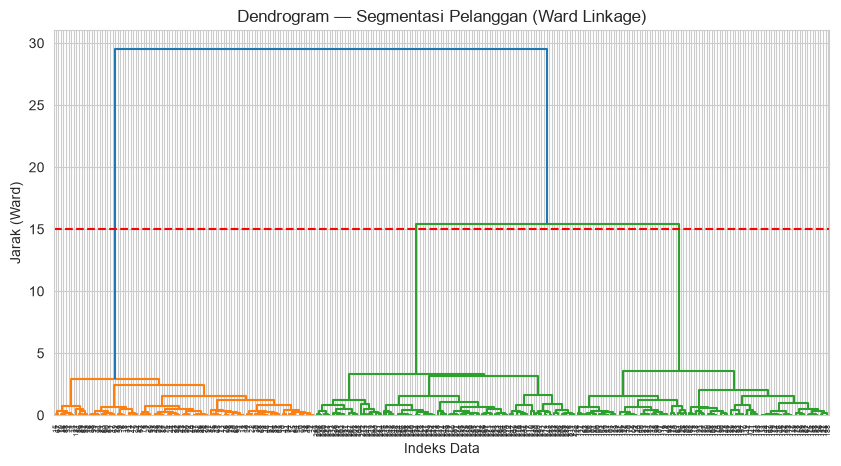

In [9]:
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(Z)
plt.title('Dendrogram — Segmentasi Pelanggan (Ward Linkage)')
plt.xlabel('Indeks Data'); plt.ylabel('Jarak (Ward)')
plt.axhline(y=15, color='red', linestyle='--')  # contoh garis potong
plt.show()

**Perbandingan dengan Metode Elbow (Langkah 3):** memotong dendrogram secara horizontal pada garis putus-putus merah (jarak ≈ 15) memotong **3 garis vertikal**, menghasilkan **3 cluster** — jumlah ini **konsisten** dengan K optimal (K=3) yang diperoleh dari Metode Elbow dan Silhouette Score sebelumnya.

Dendrogram juga memperlihatkan tiga kelompok besar yang bergabung pada ketinggian (jarak Ward) yang jauh lebih tinggi dibandingkan penggabungan-penggabungan kecil di dalamnya — celah vertikal terpanjang inilah yang menandakan pembagian tiga cluster sebagai pembagian paling alami untuk dataset ini. Hasil ini memperkuat kesimpulan bahwa **K-Means dan Hierarchical Clustering (Ward linkage) sepakat** dalam menemukan struktur tiga segmen pelanggan pada dataset sintetis ini.

## Kesimpulan

### Apa yang Dipelajari
Pada pertemuan kesebelas ini, saya mempelajari **Unsupervised Learning** melalui teknik clustering, yaitu pengelompokan data **tanpa label target**. Materi mencakup cara kerja **K-Means** (inisialisasi `k-means++`, iterasi penugasan titik ke centroid terdekat, dan minimisasi WCSS), penentuan jumlah cluster optimal dengan **Metode Elbow** dan **Silhouette Score** sebagai pembanding, pentingnya `StandardScaler` agar fitur dengan skala berbeda (pendapatan tahunan vs skor belanja) mendapat bobot setara, serta **Hierarchical Clustering** dengan `linkage(method='ward')` dan pembacaan **dendrogram** sebagai metode pembanding.

### Temuan Utama
- Metode Elbow menunjukkan siku yang jelas di **K=3**: WCSS turun tajam dari 600,0 (K=1) ke 161,7 (K=2) lalu ke 44,6 (K=3), namun setelah itu penurunannya melandai (37,9 pada K=4).
- **Silhouette Score tertinggi juga diperoleh pada K=3 (0,695)**, mengungguli K=2 (0,634) dan K=4 (0,580) — kedua metode saling mengonfirmasi sehingga pemilihan K=3 tidak semata-mata bergantung pada penilaian visual.
- Ketiga cluster yang terbentuk berukuran nyaris seimbang (100, 99, dan 101 anggota) dengan profil yang jelas berbeda: **Cluster 1** pendapatan rendah–belanja rendah (29,31 / 20,27), **Cluster 0** menengah (70,99 / 55,05), dan **Cluster 2** pendapatan tinggi–belanja tinggi (109,20 / 84,08).
- **Hierarchical Clustering menghasilkan kesimpulan yang sama**: memotong dendrogram Ward pada jarak ≈ 15 memotong 3 garis vertikal, konsisten dengan hasil K-Means dan Metode Elbow.
- Berbeda dengan supervised learning, evaluasi di sini **tidak memakai accuracy** karena tidak ada label sebenarnya — kualitas cluster dinilai dari kekompakan internal (WCSS) dan pemisahan antar cluster (Silhouette).

### Keterbatasan & Pertanyaan yang Muncul
- Dataset merupakan data **sintetis** yang sengaja dibangun dari tiga distribusi normal terpisah, sehingga Silhouette 0,695 terlalu optimistis dibandingkan data pelanggan nyata yang batas antar segmennya jauh lebih kabur.
- K-Means mengasumsikan cluster berbentuk **bulat dan berukuran mirip**, serta mengharuskan K ditentukan di awal. Bagaimana hasilnya jika segmen pelanggan berbentuk memanjang atau bersarang — apakah **DBSCAN** atau **Gaussian Mixture Model** lebih tepat?
- Hanya dua fitur numerik yang digunakan sehingga cluster mudah divisualisasikan dalam 2D. Pada data nyata dengan puluhan fitur, apakah perlu **PCA** terlebih dahulu, dan bagaimana menginterpretasikan cluster setelah dimensinya direduksi?
